# imports and paths

In [1]:
from __future__ import annotations

import json
import re
import zipfile
from collections import defaultdict
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pydicom
from pydicom.uid import ImplicitVRLittleEndian
from tqdm.auto import tqdm

MEDGS_ROOT = Path("/opt/jupyterhub/fast/mtm_medgs_stack")
REPO_ROOT = MEDGS_ROOT / "src" / "MedGS"
DATA_ROOT = MEDGS_ROOT / "data" / "tcia_4d_lung"

METADATA_DIR = DATA_ROOT / "metadata"
ZIP_ROOT = DATA_ROOT / "raw" / "series_zips"
DICOM_ROOT = DATA_ROOT / "raw" / "dicom_by_series"
PROCESSED_ROOT = DATA_ROOT / "processed"

SERIES_JSON = METADATA_DIR / "series.json"
SERIES_SUMMARY_CSV = METADATA_DIR / "series_summary.csv"
DOWNLOAD_LOG_CSV = METADATA_DIR / "download_log.csv"

for path in [METADATA_DIR, ZIP_ROOT, DICOM_ROOT, PROCESSED_ROOT]:
    print(f"{path}: exists={path.exists()}")

/opt/jupyterhub/fast/mtm_medgs_stack/data/tcia_4d_lung/metadata: exists=True
/opt/jupyterhub/fast/mtm_medgs_stack/data/tcia_4d_lung/raw/series_zips: exists=True
/opt/jupyterhub/fast/mtm_medgs_stack/data/tcia_4d_lung/raw/dicom_by_series: exists=True
/opt/jupyterhub/fast/mtm_medgs_stack/data/tcia_4d_lung/processed: exists=True


# small utility functions

In [2]:
def load_json(path: Path) -> object:
    """Load a JSON file from disk."""
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def safe_name(value: object) -> str:
    """Convert an arbitrary metadata value into a filesystem-safe name."""
    text = str(value) if value is not None else "UNKNOWN"
    return re.sub(r"[^A-Za-z0-9._-]+", "_", text)


def parse_gated_phase(series_description: str) -> Optional[float]:
    """Extract respiratory gating phase from a TCIA 4D-Lung SeriesDescription.

    Examples:
        'P4^P100^S113^I0, Gated, 70.0%' -> 70.0
        '..., Gated, 0.0%' -> 0.0
    """
    match = re.search(r"Gated,\s*([0-9]+(?:\.[0-9]+)?)%", series_description or "")
    if match is None:
        return None
    return float(match.group(1))


def count_files(path: Path, pattern: str = "*") -> int:
    """Count files recursively under a path."""
    if not path.exists():
        return 0
    return sum(1 for p in path.rglob(pattern) if p.is_file())


def human_size(num_bytes: int) -> str:
    """Format a byte count as a human-readable size."""
    units = ["B", "KB", "MB", "GB", "TB"]
    size = float(num_bytes)
    for unit in units:
        if size < 1024 or unit == units[-1]:
            return f"{size:.2f} {unit}"
        size /= 1024
    return f"{size:.2f} TB"

# load TCIA manifest and summarize series

In [3]:
series = load_json(SERIES_JSON)
series_df = pd.DataFrame(series)

series_df["GatedPhase"] = series_df["SeriesDescription"].map(parse_gated_phase)
series_df["ImageCount"] = pd.to_numeric(series_df["ImageCount"], errors="coerce").astype("Int64")

print("Rows:", len(series_df))
display(series_df.head())

summary = (
    series_df
    .groupby(["PatientID", "Modality"], dropna=False)
    .agg(
        series_count=("SeriesInstanceUID", "count"),
        image_count=("ImageCount", "sum"),
        phases=("GatedPhase", lambda x: sorted(v for v in x.dropna().unique())),
    )
    .reset_index()
    .sort_values(["PatientID", "Modality"])
)

display(summary.head(30))

Rows: 6690


,SeriesInstanceUID,StudyInstanceUID,Modality,ProtocolName,SeriesDate,SeriesDescription,BodyPartExamined,SeriesNumber,Collection,PatientID,...,ImageCount,TimeStamp,LicenseName,LicenseURI,CollectionURI,FileSize,DateReleased,StudyDesc,StudyDate,GatedPhase
0,1.3.6.1.4.1.14519.5.2.1.6834.5010.189721824525...,1.3.6.1.4.1.14519.5.2.1.6834.5010.552215730027...,CT,5.1 4DCT & ITV FB + 4D + INSP/EXP,1997-10-03 00:00:00.0,"P4^P100^S113^I0, Gated, 70.0%",LUNG,507,4D-Lung,100_HM10395,...,50,2015-07-20 17:58:54.0,Creative Commons Attribution 3.0 Unported License,http://creativecommons.org/licenses/by/3.0/,https://doi.org/10.7937/K9/TCIA.2016.ELN8YGLE,26405988,2016-10-19 00:00:00.0,p4,1997-10-03 00:00:00.0,70.0
1,1.3.6.1.4.1.14519.5.2.1.6834.5010.336250251691...,1.3.6.1.4.1.14519.5.2.1.6834.5010.980344486630...,CT,5.1 4DCT & ITV FB + 4D + INSP/EXP,1997-10-07 00:00:00.0,"P4^P100^S116^I0, Gated, 70.0%",LUNG,507,4D-Lung,100_HM10395,...,50,2015-07-20 17:40:07.0,Creative Commons Attribution 3.0 Unported License,http://creativecommons.org/licenses/by/3.0/,https://doi.org/10.7937/K9/TCIA.2016.ELN8YGLE,26405988,2016-10-19 00:00:00.0,p4,1997-10-07 00:00:00.0,70.0
2,1.3.6.1.4.1.14519.5.2.1.6834.5010.227929163446...,1.3.6.1.4.1.14519.5.2.1.6834.5010.157653211810...,CT,5.1 4DCT & ITV FB + 4D + INSP/EXP,1997-09-18 00:00:00.0,"P4^P100^S104^I0, Gated, 30.0%",LUNG,503,4D-Lung,100_HM10395,...,50,2015-07-20 17:56:27.0,Creative Commons Attribution 3.0 Unported License,http://creativecommons.org/licenses/by/3.0/,https://doi.org/10.7937/K9/TCIA.2016.ELN8YGLE,26405988,2016-10-19 00:00:00.0,p4,1997-09-18 00:00:00.0,30.0
3,1.3.6.1.4.1.14519.5.2.1.6834.5010.925990093742...,1.3.6.1.4.1.14519.5.2.1.6834.5010.256783235670...,CT,5.1 4DCT & ITV FB + 4D + INSP/EXP,1997-10-14 00:00:00.0,"P4^P100^S123^I0, Gated, 20.0%",LUNG,502,4D-Lung,100_HM10395,...,50,2015-07-20 17:55:30.0,Creative Commons Attribution 3.0 Unported License,http://creativecommons.org/licenses/by/3.0/,https://doi.org/10.7937/K9/TCIA.2016.ELN8YGLE,26405988,2016-10-19 00:00:00.0,p4,1997-10-14 00:00:00.0,20.0
4,1.3.6.1.4.1.14519.5.2.1.6834.5010.139116724721...,1.3.6.1.4.1.14519.5.2.1.6834.5010.980344486630...,CT,5.1 4DCT & ITV FB + 4D + INSP/EXP,1997-10-07 00:00:00.0,"P4^P100^S116^I0, Gated, 10.0%",LUNG,501,4D-Lung,100_HM10395,...,50,2015-07-20 17:51:12.0,Creative Commons Attribution 3.0 Unported License,http://creativecommons.org/licenses/by/3.0/,https://doi.org/10.7937/K9/TCIA.2016.ELN8YGLE,26405988,2016-10-19 00:00:00.0,p4,1997-10-07 00:00:00.0,10.0


,PatientID,Modality,series_count,image_count,phases
0,100_HM10395,CT,340,17920,"[0.0, 10.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0..."
1,100_HM10395,RTSTRUCT,10,10,"[0.0, 10.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0..."
2,101_HM10395,CT,110,6490,"[0.0, 10.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0..."
3,101_HM10395,RTSTRUCT,10,10,"[0.0, 10.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0..."
4,102_HM10395,CT,170,9330,"[0.0, 10.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0..."
5,102_HM10395,RTSTRUCT,10,10,"[0.0, 10.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0..."
6,103_HM10395,CT,380,21080,"[0.0, 10.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0..."
7,103_HM10395,RTSTRUCT,10,10,"[0.0, 10.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0..."
8,104_HM10395,CT,320,16530,"[0.0, 10.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0..."
9,104_HM10395,RTSTRUCT,10,10,"[0.0, 10.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0..."


# inspect download status

In [4]:
zip_files = sorted(ZIP_ROOT.glob("*/*.zip"))
zip_sizes = [p.stat().st_size for p in zip_files]

print("Downloaded ZIP files:", len(zip_files))
print("Total ZIP size:", human_size(sum(zip_sizes)))

by_patient_zip = defaultdict(list)
for path in zip_files:
    by_patient_zip[path.parent.name].append(path)

zip_summary = pd.DataFrame(
    [
        {
            "PatientID": patient_id,
            "zip_count": len(paths),
            "zip_size": sum(p.stat().st_size for p in paths),
            "zip_size_human": human_size(sum(p.stat().st_size for p in paths)),
        }
        for patient_id, paths in sorted(by_patient_zip.items())
    ]
)

display(zip_summary)

Downloaded ZIP files: 6690
Total ZIP size: 93.29 GB


,PatientID,zip_count,zip_size,zip_size_human
0,100_HM10395,350,5569523820,5.19 GB
1,101_HM10395,120,1880356337,1.75 GB
2,102_HM10395,180,2778752037,2.59 GB
3,103_HM10395,390,6400852272,5.96 GB
4,104_HM10395,330,5174383362,4.82 GB
5,105_HM10395,350,5515958988,5.14 GB
6,106_HM10395,330,5145431956,4.79 GB
7,107_HM10395,290,4148118733,3.86 GB
8,108_HM10395,330,4891420686,4.56 GB
9,109_HM10395,380,5690646803,5.30 GB


# choose one patient and list ZIP series

In [5]:
PATIENT_ID = "100_HM10395"

patient_series = (
    series_df[series_df["PatientID"] == PATIENT_ID]
    .copy()
    .sort_values(["GatedPhase", "SeriesDescription", "SeriesInstanceUID"])
)

print("Patient:", PATIENT_ID)
print("Series:", len(patient_series))
print("Images:", patient_series["ImageCount"].sum())

display(
    patient_series[
        [
            "PatientID",
            "Modality",
            "ImageCount",
            "GatedPhase",
            "SeriesDescription",
            "SeriesInstanceUID",
        ]
    ].head(50)
)

Patient: 100_HM10395
Series: 350
Images: 17930


,PatientID,Modality,ImageCount,GatedPhase,SeriesDescription,SeriesInstanceUID
37,100_HM10395,CT,50,0.0,"P4^P100^S100^I0, Gated, 0.0%",1.3.6.1.4.1.14519.5.2.1.6834.5010.322628904903...
6686,100_HM10395,CT,50,0.0,"P4^P100^S101^I0, Gated, 0.0%",1.3.6.1.4.1.14519.5.2.1.6834.5010.259228284494...
181,100_HM10395,CT,50,0.0,"P4^P100^S102^I0, Gated, 0.0%",1.3.6.1.4.1.14519.5.2.1.6834.5010.251154597608...
114,100_HM10395,CT,50,0.0,"P4^P100^S103^I0, Gated, 0.0%",1.3.6.1.4.1.14519.5.2.1.6834.5010.339657150197...
261,100_HM10395,CT,50,0.0,"P4^P100^S104^I0, Gated, 0.0%",1.3.6.1.4.1.14519.5.2.1.6834.5010.287101923352...
202,100_HM10395,CT,50,0.0,"P4^P100^S105^I0, Gated, 0.0%",1.3.6.1.4.1.14519.5.2.1.6834.5010.266228966386...
253,100_HM10395,CT,50,0.0,"P4^P100^S106^I0, Gated, 0.0%",1.3.6.1.4.1.14519.5.2.1.6834.5010.177273543393...
73,100_HM10395,CT,50,0.0,"P4^P100^S107^I0, Gated, 0.0%",1.3.6.1.4.1.14519.5.2.1.6834.5010.149835507660...
54,100_HM10395,CT,50,0.0,"P4^P100^S108^I0, Gated, 0.0%",1.3.6.1.4.1.14519.5.2.1.6834.5010.190033439129...
218,100_HM10395,CT,50,0.0,"P4^P100^S109^I0, Gated, 0.0%",1.3.6.1.4.1.14519.5.2.1.6834.5010.242452811624...


# unzip one patient, resumable

In [9]:
def unzip_patient(patient_id: str, overwrite: bool = False) -> pd.DataFrame:
    """Extract all downloaded series ZIP files for a single patient.

    The function creates one output directory per SeriesInstanceUID and writes
    a small '.extracted_ok' marker to make the operation resumable.
    """
    patient_zip_dir = ZIP_ROOT / patient_id
    patient_out_dir = DICOM_ROOT / patient_id
    patient_out_dir.mkdir(parents=True, exist_ok=True)

    rows = []
    zip_paths = sorted(patient_zip_dir.glob("*.zip"))

    for zip_path in tqdm(zip_paths, desc=f"Unzipping {patient_id}"):
        series_uid = zip_path.stem
        out_dir = patient_out_dir / series_uid
        marker = out_dir / ".extracted_ok"

        if marker.exists() and not overwrite:
            status = "skipped_existing"
        else:
            out_dir.mkdir(parents=True, exist_ok=True)
            try:
                with zipfile.ZipFile(zip_path, "r") as zf:
                    zf.extractall(out_dir)
                marker.write_text("ok\n", encoding="utf-8")
                status = "extracted"
            except Exception as exc:
                status = f"failed: {exc!r}"

        extracted_files = count_files(out_dir) - int(marker.exists())
        rows.append(
            {
                "PatientID": patient_id,
                "SeriesInstanceUID": series_uid,
                "status": status,
                "zip_path": str(zip_path),
                "out_dir": str(out_dir),
                "extracted_files": extracted_files,
            }
        )

    return pd.DataFrame(rows)


unzip_df = unzip_patient(PATIENT_ID, overwrite=False)
display(unzip_df.head())
display(unzip_df["status"].value_counts())
print("Extracted patient size:")
!du -sh {DICOM_ROOT / PATIENT_ID}

Unzipping 100_HM10395:   0%|          | 0/350 [00:00<?, ?it/s]

,PatientID,SeriesInstanceUID,status,zip_path,out_dir,extracted_files
0,100_HM10395,1.3.6.1.4.1.14519.5.2.1.6834.5010.100948762295...,extracted,/opt/jupyterhub/fast/mtm_medgs_stack/data/tcia...,/opt/jupyterhub/fast/mtm_medgs_stack/data/tcia...,51
1,100_HM10395,1.3.6.1.4.1.14519.5.2.1.6834.5010.101259327592...,extracted,/opt/jupyterhub/fast/mtm_medgs_stack/data/tcia...,/opt/jupyterhub/fast/mtm_medgs_stack/data/tcia...,51
2,100_HM10395,1.3.6.1.4.1.14519.5.2.1.6834.5010.101387802522...,extracted,/opt/jupyterhub/fast/mtm_medgs_stack/data/tcia...,/opt/jupyterhub/fast/mtm_medgs_stack/data/tcia...,51
3,100_HM10395,1.3.6.1.4.1.14519.5.2.1.6834.5010.101948232412...,extracted,/opt/jupyterhub/fast/mtm_medgs_stack/data/tcia...,/opt/jupyterhub/fast/mtm_medgs_stack/data/tcia...,51
4,100_HM10395,1.3.6.1.4.1.14519.5.2.1.6834.5010.103521604337...,extracted,/opt/jupyterhub/fast/mtm_medgs_stack/data/tcia...,/opt/jupyterhub/fast/mtm_medgs_stack/data/tcia...,143


status
extracted    350
Name: count, dtype: int64

Extracted patient size:
8,9G	/opt/jupyterhub/fast/mtm_medgs_stack/data/tcia_4d_lung/raw/dicom_by_series/100_HM10395


# find DICOM files and read lightweight metadata

In [7]:
def find_dicom_files(series_dir: Path) -> list[Path]:
    """Find candidate DICOM files in a series directory.

    TCIA ZIPs may contain files without a '.dcm' extension, so we collect all
    regular files except marker files.
    """
    return sorted(
        p for p in series_dir.rglob("*")
        if p.is_file() and p.name != ".extracted_ok"
    )


def read_dicom_header(path: Path) -> pydicom.Dataset:
    """Read DICOM metadata without loading pixel data."""
    return pydicom.dcmread(str(path), stop_before_pixels=True, force=True)


def summarize_dicom_series(patient_id: str, max_series: Optional[int] = None) -> pd.DataFrame:
    """Create a compact metadata summary for extracted DICOM series."""
    patient_dir = DICOM_ROOT / patient_id
    series_dirs = sorted(p for p in patient_dir.iterdir() if p.is_dir())

    if max_series is not None:
        series_dirs = series_dirs[:max_series]

    rows = []
    for series_dir in tqdm(series_dirs, desc=f"Reading headers for {patient_id}"):
        files = find_dicom_files(series_dir)
        if not files:
            continue

        try:
            ds = read_dicom_header(files[0])
        except Exception as exc:
            rows.append(
                {
                    "PatientID": patient_id,
                    "SeriesInstanceUID": series_dir.name,
                    "status": f"failed: {exc!r}",
                    "file_count": len(files),
                }
            )
            continue

        rows.append(
            {
                "PatientID": getattr(ds, "PatientID", patient_id),
                "SeriesInstanceUID": getattr(ds, "SeriesInstanceUID", series_dir.name),
                "StudyInstanceUID": getattr(ds, "StudyInstanceUID", None),
                "Modality": getattr(ds, "Modality", None),
                "SeriesDescription": getattr(ds, "SeriesDescription", None),
                "ProtocolName": getattr(ds, "ProtocolName", None),
                "Rows": getattr(ds, "Rows", None),
                "Columns": getattr(ds, "Columns", None),
                "SliceThickness": getattr(ds, "SliceThickness", None),
                "PixelSpacing": getattr(ds, "PixelSpacing", None),
                "file_count": len(files),
                "first_file": str(files[0]),
                "status": "ok",
            }
        )

    result = pd.DataFrame(rows)
    if "SeriesDescription" in result:
        result["GatedPhase"] = result["SeriesDescription"].map(parse_gated_phase)
    return result


dicom_summary = summarize_dicom_series(PATIENT_ID)
display(dicom_summary.head(30))
display(dicom_summary["GatedPhase"].value_counts(dropna=False).sort_index())

Reading headers for 100_HM10395:   0%|          | 0/350 [00:00<?, ?it/s]

,PatientID,SeriesInstanceUID,StudyInstanceUID,Modality,SeriesDescription,ProtocolName,Rows,Columns,SliceThickness,PixelSpacing,file_count,first_file,status,GatedPhase
0,100_HM10395,1.3.6.1.4.1.14519.5.2.1.6834.5010.100948762295...,1.3.6.1.4.1.14519.5.2.1.6834.5010.256678693103...,CT,"P4^P100^S110^I0, Gated, 80.0%",5.1 4DCT & ITV FB + 4D + INSP/EXP,512.0,512.0,3.0,"[0.878906, 0.878906]",51,/opt/jupyterhub/fast/mtm_medgs_stack/data/tcia...,ok,80.0
1,100_HM10395,1.3.6.1.4.1.14519.5.2.1.6834.5010.101259327592...,1.3.6.1.4.1.14519.5.2.1.6834.5010.232289408791...,CT,"P4^P100^S118^I0, Gated, 90.0%",5.1 4DCT & ITV FB + 4D + INSP/EXP,512.0,512.0,3.0,"[0.878906, 0.878906]",51,/opt/jupyterhub/fast/mtm_medgs_stack/data/tcia...,ok,90.0
2,100_HM10395,1.3.6.1.4.1.14519.5.2.1.6834.5010.101387802522...,1.3.6.1.4.1.14519.5.2.1.6834.5010.157653211810...,CT,"P4^P100^S104^I0, Gated, 10.0%",5.1 4DCT & ITV FB + 4D + INSP/EXP,512.0,512.0,3.0,"[0.878906, 0.878906]",51,/opt/jupyterhub/fast/mtm_medgs_stack/data/tcia...,ok,10.0
3,100_HM10395,1.3.6.1.4.1.14519.5.2.1.6834.5010.101948232412...,1.3.6.1.4.1.14519.5.2.1.6834.5010.254941569710...,CT,"P4^P100^S112^I0, Gated, 60.0%",5.1 4DCT & ITV FB + 4D + INSP/EXP,512.0,512.0,3.0,"[0.878906, 0.878906]",51,/opt/jupyterhub/fast/mtm_medgs_stack/data/tcia...,ok,60.0
4,100_HM10395,1.3.6.1.4.1.14519.5.2.1.6834.5010.103521604337...,1.3.6.1.4.1.14519.5.2.1.6834.5010.465205689126...,CT,"P4^P100^S300^I00011, Gated, 80.0%A",None,512.0,512.0,3.0,"[0.9766, 0.9766]",143,/opt/jupyterhub/fast/mtm_medgs_stack/data/tcia...,ok,80.0
5,100_HM10395,1.3.6.1.4.1.14519.5.2.1.6834.5010.104367227242...,1.3.6.1.4.1.14519.5.2.1.6834.5010.465205689126...,CT,"P4^P100^S300^I00006, Gated, 30.0%A",None,512.0,512.0,3.0,"[0.9766, 0.9766]",143,/opt/jupyterhub/fast/mtm_medgs_stack/data/tcia...,ok,30.0
6,100_HM10395,1.3.6.1.4.1.14519.5.2.1.6834.5010.105031608124...,1.3.6.1.4.1.14519.5.2.1.6834.5010.256630914219...,CT,"P4^P100^S107^I0, Gated, 30.0%",5.1 4DCT & ITV FB + 4D + INSP/EXP,512.0,512.0,3.0,"[0.878906, 0.878906]",51,/opt/jupyterhub/fast/mtm_medgs_stack/data/tcia...,ok,30.0
7,100_HM10395,1.3.6.1.4.1.14519.5.2.1.6834.5010.108009258467...,1.3.6.1.4.1.14519.5.2.1.6834.5010.178226947942...,CT,"P4^P100^S130^I0, Gated, 70.0%",5.1 4DCT & ITV FB + 4D + INSP/EXP,512.0,512.0,3.0,"[0.878906, 0.878906]",51,/opt/jupyterhub/fast/mtm_medgs_stack/data/tcia...,ok,70.0
8,100_HM10395,1.3.6.1.4.1.14519.5.2.1.6834.5010.109895801060...,1.3.6.1.4.1.14519.5.2.1.6834.5010.333760633985...,CT,"P4^P100^S109^I0, Gated, 70.0%",5.1 4DCT & ITV FB + 4D + INSP/EXP,512.0,512.0,3.0,"[0.878906, 0.878906]",51,/opt/jupyterhub/fast/mtm_medgs_stack/data/tcia...,ok,70.0
9,100_HM10395,1.3.6.1.4.1.14519.5.2.1.6834.5010.113235474372...,1.3.6.1.4.1.14519.5.2.1.6834.5010.247230480138...,CT,"P4^P100^S132^I0, Gated, 60.0%",5.1 4DCT & ITV FB + 4D + INSP/EXP,512.0,512.0,3.0,"[0.878906, 0.878906]",51,/opt/jupyterhub/fast/mtm_medgs_stack/data/tcia...,ok,60.0


GatedPhase
0.0     35
10.0    35
20.0    35
30.0    35
40.0    35
50.0    35
60.0    35
70.0    35
80.0    35
90.0    35
Name: count, dtype: int64

# preview one DICOM slice

Series: 1.3.6.1.4.1.14519.5.2.1.6834.5010.131158498639269354544228677654
Phase: 0.0
File: /opt/jupyterhub/fast/mtm_medgs_stack/data/tcia_4d_lung/raw/dicom_by_series/100_HM10395/1.3.6.1.4.1.14519.5.2.1.6834.5010.131158498639269354544228677654/00000026.dcm
Shape: (512, 512)


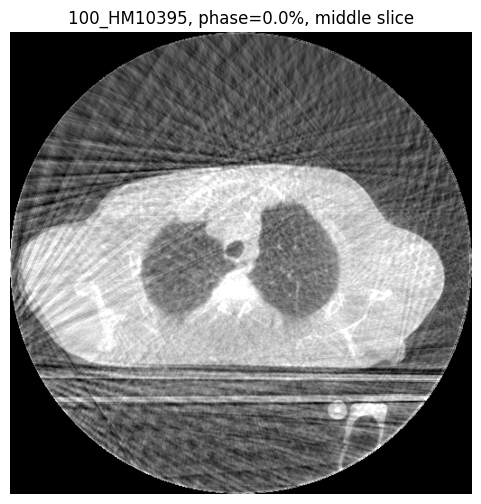

In [14]:
def read_dicom_with_pixels(path: Path) -> pydicom.Dataset:
    """Read a DICOM file and patch missing transfer syntax if needed.

    Some TCIA files may lack File Meta Information / TransferSyntaxUID.
    For these CT slices, assuming Implicit VR Little Endian is a practical fallback.
    """
    ds = pydicom.dcmread(str(path), force=True)

    if not hasattr(ds, "file_meta") or ds.file_meta is None:
        ds.file_meta = pydicom.dataset.FileMetaDataset()

    if not hasattr(ds.file_meta, "TransferSyntaxUID"):
        ds.file_meta.TransferSyntaxUID = ImplicitVRLittleEndian
        ds.is_little_endian = True
        ds.is_implicit_VR = True

    return ds


def dicom_pixels_to_uint8(ds: pydicom.Dataset) -> np.ndarray:
    """Convert a DICOM pixel array to uint8 using robust percentile windowing."""
    if not hasattr(ds, "file_meta") or ds.file_meta is None:
        ds.file_meta = pydicom.dataset.FileMetaDataset()

    if not hasattr(ds.file_meta, "TransferSyntaxUID"):
        ds.file_meta.TransferSyntaxUID = ImplicitVRLittleEndian
        ds.is_little_endian = True
        ds.is_implicit_VR = True

    arr = ds.pixel_array.astype(np.float32)

    slope = float(getattr(ds, "RescaleSlope", 1.0))
    intercept = float(getattr(ds, "RescaleIntercept", 0.0))
    arr = arr * slope + intercept

    lo, hi = np.percentile(arr, [1, 99])
    if hi <= lo:
        hi = lo + 1.0

    arr = np.clip((arr - lo) / (hi - lo), 0.0, 1.0)
    return (arr * 255).astype(np.uint8)


# Pick a CT series with a detected respiratory phase.
candidate = (
    dicom_summary[
        (dicom_summary["Modality"] == "CT")
        & (dicom_summary["GatedPhase"].notna())
        & (dicom_summary["status"] == "ok")
        ]
    .sort_values(["GatedPhase", "SeriesInstanceUID"])
    .iloc[0]
)

series_dir = DICOM_ROOT / PATIENT_ID / candidate["SeriesInstanceUID"]
files = find_dicom_files(series_dir)

middle_file = files[len(files) // 2]
ds = read_dicom_with_pixels(middle_file)

img = dicom_pixels_to_uint8(ds)

print("Series:", candidate["SeriesInstanceUID"])
print("Phase:", candidate["GatedPhase"])
print("File:", middle_file)
print("Shape:", img.shape)

plt.figure(figsize=(6, 6))
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.title(f"{PATIENT_ID}, phase={candidate['GatedPhase']}%, middle slice")
plt.show()

In [9]:
out_csv = PROCESSED_ROOT / f"{PATIENT_ID}_dicom_summary.csv"
dicom_summary.to_csv(out_csv, index=False)
print(f"Saved: {out_csv}")

Saved: /opt/jupyterhub/fast/mtm_medgs_stack/data/tcia_4d_lung/processed/100_HM10395_dicom_summary.csv


# sortowania i wyświetlania serii

In [17]:
def has_dicom_pixel_data(ds: pydicom.Dataset) -> bool:
    """Return True if the DICOM dataset contains image pixel data."""
    return (
            "PixelData" in ds
            or "FloatPixelData" in ds
            or "DoubleFloatPixelData" in ds
    )


def dicom_dataset_sort_key(path: Path, ds: pydicom.Dataset) -> tuple:
    """Return a robust sorting key for DICOM image slices.

    Prefer ImagePositionPatient[z], then SliceLocation, then InstanceNumber.
    """
    image_position = getattr(ds, "ImagePositionPatient", None)
    if image_position is not None and len(image_position) >= 3:
        return (0, float(image_position[2]))

    slice_location = getattr(ds, "SliceLocation", None)
    if slice_location is not None:
        return (1, float(slice_location))

    instance_number = getattr(ds, "InstanceNumber", None)
    if instance_number is not None:
        return (2, int(instance_number))

    return (3, str(path))


def load_sorted_dicom_image_files(series_dir: Path) -> list[tuple[Path, pydicom.Dataset]]:
    """Find, read, filter, and sort DICOM image files belonging to one series.

    This skips DICOM files that do not contain PixelData.
    """
    rows = []

    for path in find_dicom_files(series_dir):
        try:
            ds = read_dicom_with_pixels(path)
        except Exception as exc:
            print(f"Skipping unreadable DICOM: {path} :: {exc!r}")
            continue

        if not has_dicom_pixel_data(ds):
            continue

        rows.append((path, ds))

    rows.sort(key=lambda item: dicom_dataset_sort_key(item[0], item[1]))
    return rows


def show_dicom_series_grid(
        series_dir: Path,
        n_images: int = 16,
        cols: int = 4,
        title: Optional[str] = None,
) -> list[Path]:
    """Display evenly sampled DICOM image slices from one series as a grid."""
    rows_with_ds = load_sorted_dicom_image_files(series_dir)

    if not rows_with_ds:
        raise ValueError(f"No DICOM image files with PixelData found in {series_dir}")

    indices = np.linspace(
        0,
        len(rows_with_ds) - 1,
        min(n_images, len(rows_with_ds)),
    ).round().astype(int)

    selected = [rows_with_ds[i] for i in indices]

    n_selected = len(selected)
    plot_rows = int(np.ceil(n_selected / cols))

    fig, axes = plt.subplots(plot_rows, cols, figsize=(4 * cols, 4 * plot_rows))
    axes = np.asarray(axes).reshape(-1)

    for ax, (file_path, ds), idx in zip(axes, selected, indices):
        img = dicom_pixels_to_uint8(ds)

        ax.imshow(img, cmap="gray")
        ax.set_title(f"slice {idx}", fontsize=10)
        ax.axis("off")

    for ax in axes[n_selected:]:
        ax.axis("off")

    if title is not None:
        fig.suptitle(title, fontsize=14)

    plt.tight_layout()
    plt.show()

    return [path for path, _ in selected]

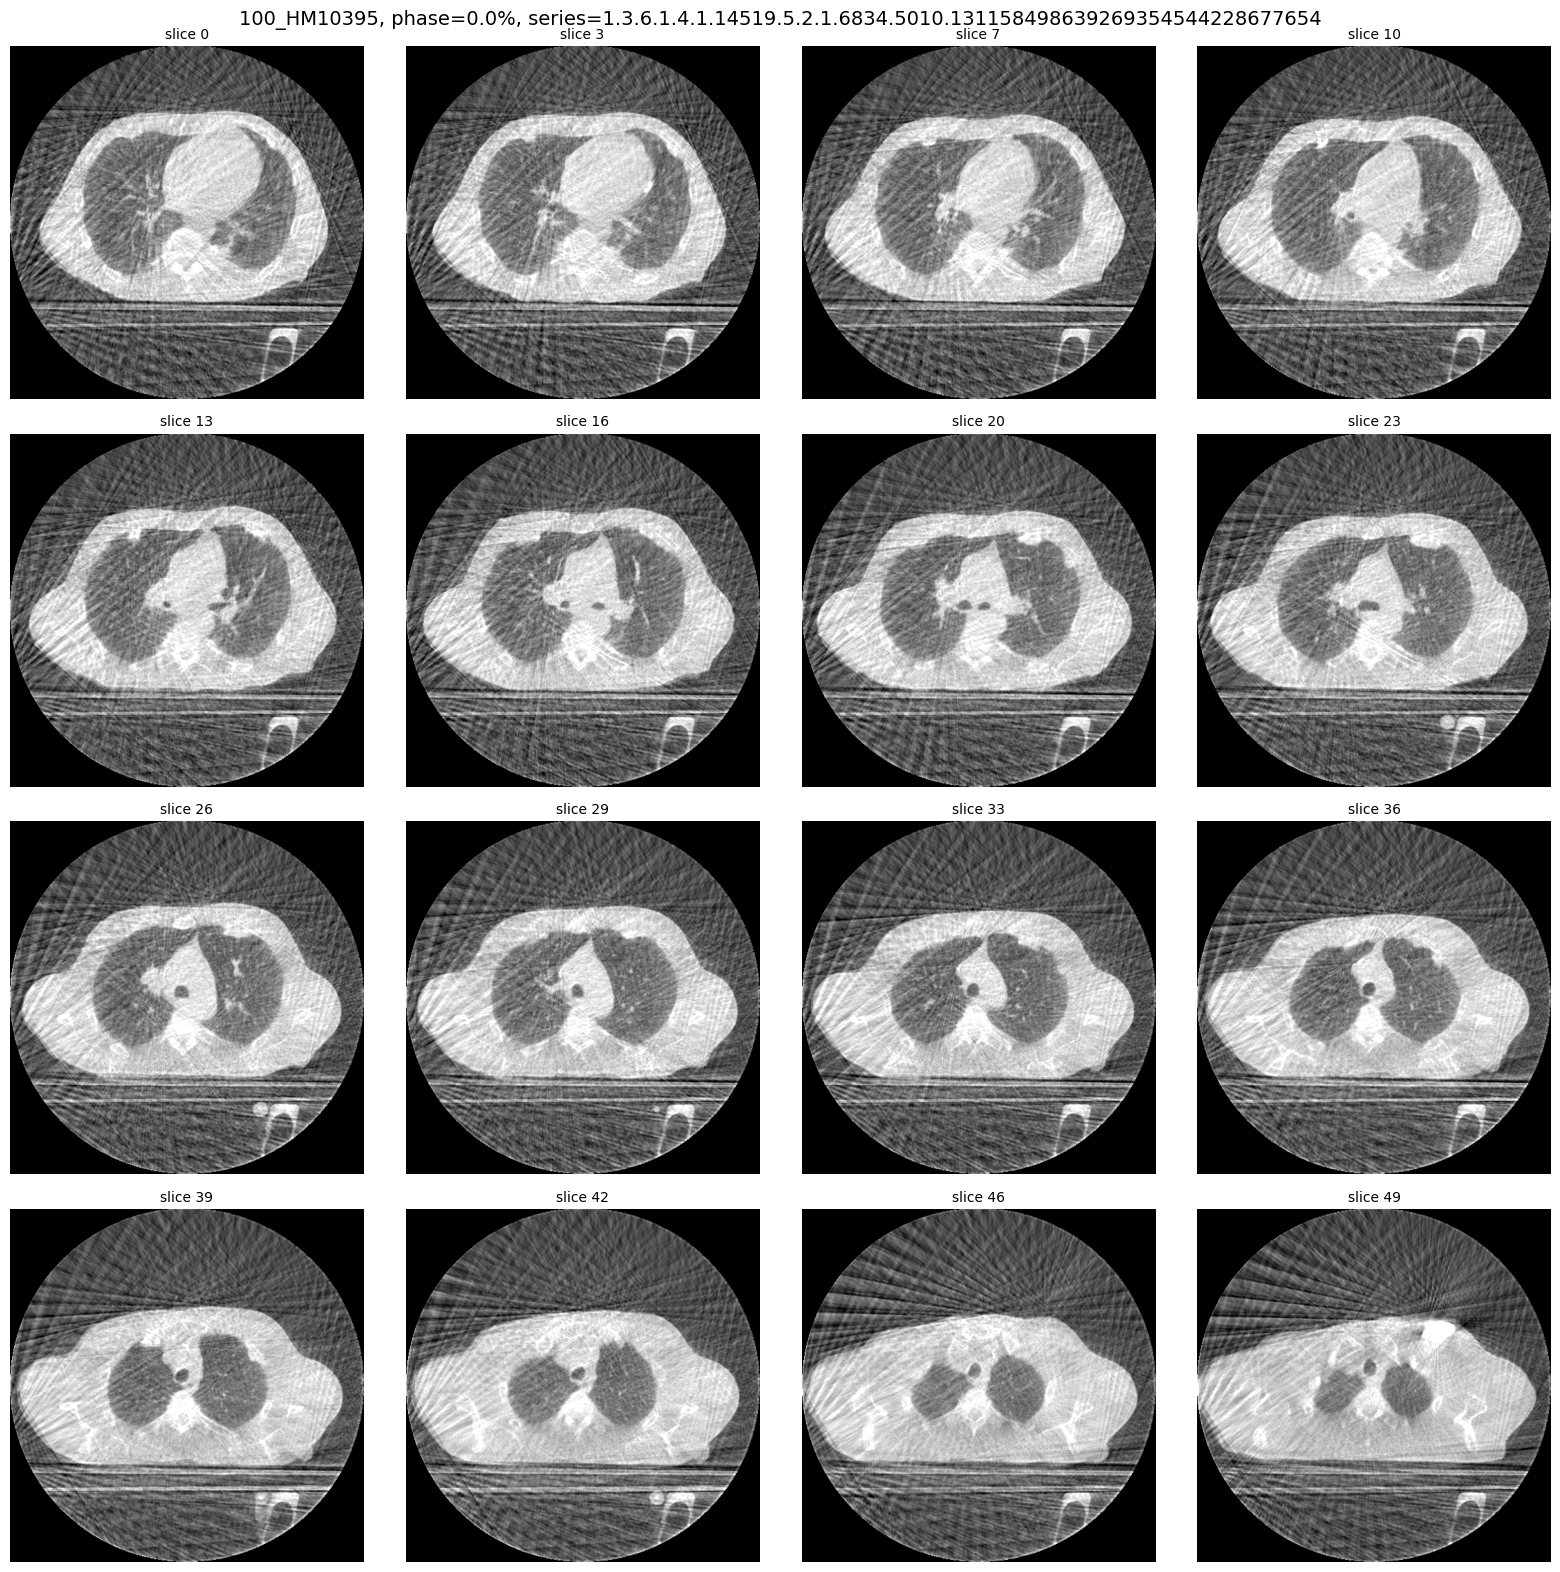

Displayed files:
/opt/jupyterhub/fast/mtm_medgs_stack/data/tcia_4d_lung/raw/dicom_by_series/100_HM10395/1.3.6.1.4.1.14519.5.2.1.6834.5010.131158498639269354544228677654/00000037.dcm
/opt/jupyterhub/fast/mtm_medgs_stack/data/tcia_4d_lung/raw/dicom_by_series/100_HM10395/1.3.6.1.4.1.14519.5.2.1.6834.5010.131158498639269354544228677654/00000020.dcm
/opt/jupyterhub/fast/mtm_medgs_stack/data/tcia_4d_lung/raw/dicom_by_series/100_HM10395/1.3.6.1.4.1.14519.5.2.1.6834.5010.131158498639269354544228677654/00000041.dcm
/opt/jupyterhub/fast/mtm_medgs_stack/data/tcia_4d_lung/raw/dicom_by_series/100_HM10395/1.3.6.1.4.1.14519.5.2.1.6834.5010.131158498639269354544228677654/00000038.dcm
/opt/jupyterhub/fast/mtm_medgs_stack/data/tcia_4d_lung/raw/dicom_by_series/100_HM10395/1.3.6.1.4.1.14519.5.2.1.6834.5010.131158498639269354544228677654/00000035.dcm
/opt/jupyterhub/fast/mtm_medgs_stack/data/tcia_4d_lung/raw/dicom_by_series/100_HM10395/1.3.6.1.4.1.14519.5.2.1.6834.5010.131158498639269354544228677654/000000

In [18]:
series_dir = DICOM_ROOT / PATIENT_ID / candidate["SeriesInstanceUID"]

shown_files = show_dicom_series_grid(
    series_dir=series_dir,
    n_images=16,
    cols=4,
    title=f"{PATIENT_ID}, phase={candidate['GatedPhase']}%, series={candidate['SeriesInstanceUID']}",
)

print("Displayed files:")
for path in shown_files:
    print(path)